# Final Ranking
This notebook ranks all merchants for the BNPL firm and selects the **top 100 merchants overall**
and the **top 10 merchants in each of the 5 segments**. The choice of features is justified in `10_feature_analysis.ipynb`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import numpy as np

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/07 18:40:05 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/07 18:40:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/07 18:40:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Data

In [3]:
enr = spark.read.parquet("../data/curated/final_external_enriched")
# one row per merchant
rankings_pd = (
    enr.groupBy("merchant_abn")
    .agg(
        F.first("take_rate", ignorenulls=True).alias("take_rate"),
        F.sum("dollar_value").alias("total_dollar_value"),
        F.count("order_id").alias("num_transactions"),
    )
    .toPandas()
)

# is_essential per merchant
ess = (spark.read.parquet("../data/curated/merged_transactions_sa2.parquet")
       .select("merchant_abn", "is_essential").distinct().toPandas())

print("Merchants:", len(rankings_pd), "| unique:", rankings_pd["merchant_abn"].nunique())
print("Merchants with is_essential:", ess["merchant_abn"].nunique())

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Merchants: 4026 | unique: 4026
Merchants with is_essential: 4026


In [4]:
# customer mix per merchant
# a tag is only valid when its source value exists (the tags were built with .otherwise())
sources = {"advantage_area": "poa_irsad_decile", "socioeconomic_area": "poa_irsd_decile",
           "age_area_tag": "Median_age_persons", "mortgage_cost_tag": "Median_mortgage_repay_monthly"}
cf = spark.read.parquet("../data/curated/consumer_features")
tag_sp = cf.select(
    "consumer_id",
    *[F.coalesce(F.when(F.col(src).isNotNull(), F.col(tag)), F.lit("Unknown")).alias(tag)
      for tag, src in sources.items()]
)
tx = enr.select("merchant_abn", "consumer_id").join(tag_sp, on="consumer_id", how="inner")

targets = {"socioeconomic_area": "Higher Disadvantage", "advantage_area": "Lower Advantage",
           "age_area_tag": "Younger Area", "mortgage_cost_tag": "Higher Mortgage Cost Area"}
aggs = []
for c, label in targets.items():
    aggs += [F.sum((F.col(c) == label).cast("int")).alias(f"{c}_hit"),
             F.sum((F.col(c) != "Unknown").cast("int")).alias(f"{c}_known")]

mix = tx.groupBy("merchant_abn").agg(F.count("*").alias("n_tx"), *aggs).toPandas()
mix["merchant_abn"] = mix["merchant_abn"].astype(str)
mix = mix[mix["n_tx"] >= 30]
print("Merchants with customer mix:", len(mix))

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Merchants with customer mix: 3586


# Create Final ranking

In [5]:
# prepare features for the final ranking model
# One row per merchant, ready to be merged with teammates' components
vol = rankings_pd[["merchant_abn", "take_rate", "total_dollar_value", "num_transactions"]].copy()
vol["est_revenue"] = vol["take_rate"] / 100 * vol["total_dollar_value"]

def log01(x):
    """Log-scale min-max score (0 to 1, higher = better)."""
    l = np.log(x)
    return (l - l.min()) / (l.max() - l.min())

assert (vol["est_revenue"] > 0).all() and (vol["num_transactions"] > 0).all()   # log needs positive values

vol["score_revenue"] = log01(vol["est_revenue"])
vol["score_demand"] = log01(vol["num_transactions"])

vol.to_parquet("../data/curated/volume_scores.parquet", index=False)
print(vol.describe().round(3))

       take_rate  total_dollar_value  num_transactions  est_revenue  \
count   4026.000            4026.000          4026.000     4026.000   
mean       4.398          535781.369          3381.688    23933.339   
std        1.783         1218830.985         14146.701    58499.471   
min        0.100           10064.934             1.000       12.313   
25%        2.970           36652.804            93.000     1470.211   
50%        4.500          141397.948           418.000     5146.421   
75%        6.030          628006.259          2057.500    22933.625   
max        7.000         9857402.328        289513.000   663870.290   

       score_revenue  score_demand  
count       4026.000      4026.000  
mean           0.565         0.481  
std            0.158         0.170  
min            0.000         0.000  
25%            0.439         0.360  
50%            0.554         0.480  
75%            0.691         0.607  
max            1.000         1.000  


In [6]:
print(vol[["score_revenue", "score_demand"]].describe().round(3))

       score_revenue  score_demand
count       4026.000      4026.000
mean           0.565         0.481
std            0.158         0.170
min            0.000         0.000
25%            0.439         0.360
50%            0.554         0.480
75%            0.691         0.607
max            1.000         1.000


# Segments
We use the unique values in `category_group`, and assign a segment depending in the type of tags that are sold.


**How the categories were grouped**
Technology & Media: technology, tv_media_telecom, books_media_digital. They have electronics, media and digital content in common.

Home & Office: furniture_home, gardening, office_stationery.

Fashion, Beauty & Luxury: jewellery, health_beauty, footwear. These are personal products that include accessories and beauty items.

Leisure, Gifts & Art: gifts_hobby_novelty, antiques_art_craft, outdoor_supply, music. These are hobbies, gifts and art activities.

Vehicles & Equipment:  vehicle, equipment_rental_leasing


**Alternatives we considered**
- **Essential vs non-essential** (`start-ranking.ipynb`): only 3 segments.

In [7]:
# Map each of the 15 category_group values to one of 5 segments
segment_map = {
    "technology": "Technology & Media", "tv_media_telecom": "Technology & Media",
    "books_media_digital": "Technology & Media", "music": "Leisure, Gifts & Art",
    "furniture_home": "Home & Office", "gardening": "Home & Office",
    "office_stationery": "Home & Office",
    "jewelry": "Fashion, Beauty & Luxury", "health_beauty": "Fashion, Beauty & Luxury",
    "footwear": "Fashion, Beauty & Luxury",
    "gifts_hobby_novelty": "Leisure, Gifts & Art", "antiques_art_craft": "Leisure, Gifts & Art",
    "outdoor_supply": "Leisure, Gifts & Art",
    "vehicle": "Vehicles & Equipment", "equipment_rental_leasing": "Vehicles & Equipment",
}

# One row per merchant with its category_group
merchant_cat = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .select("merchant_abn", "category_group")
    .distinct()
    .toPandas()
)

# Each merchant should have exactly one category_group
print("One category per merchant:", merchant_cat["merchant_abn"].is_unique)

merchant_cat["segment"] = merchant_cat["category_group"].map(segment_map)
print("Unmapped merchants:", merchant_cat["segment"].isna().sum())

# Attach segments to the volume scores and check how balanced they are
vol_seg = vol.merge(merchant_cat[["merchant_abn", "category_group", "segment"]],
                    on="merchant_abn", how="left")
print(vol_seg.groupby("segment").size().sort_values())

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


One category per merchant: True
Unmapped merchants: 0
segment
Vehicles & Equipment         455
Home & Office                676
Fashion, Beauty & Luxury     761
Technology & Media          1031
Leisure, Gifts & Art        1103
dtype: int64


                                                   merchants  median_ticket  median_transactions  median_revenue
segment                  category_group                                                                         
Fashion, Beauty & Luxury jewelry                         261          150.8                295.0          3648.2
                         footwear                        185          257.2                602.0          5042.0
                         health_beauty                   315          282.8                571.0          5427.3
Home & Office            furniture_home                  182          213.6                387.5          5893.9
                         gardening                       333          312.5                489.0          6673.3
                         office_stationery               161          500.7                212.0          3220.2
Leisure, Gifts & Art     gifts_hobby_novelty             324           97.1                678.5

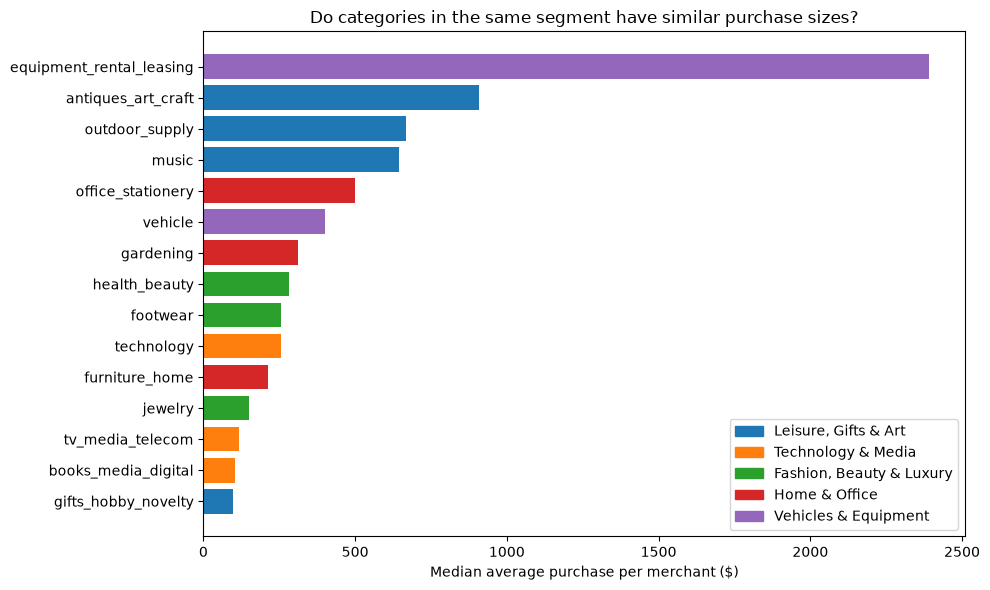

In [8]:
# Do the category groups inside each segment behave alike?
from matplotlib.patches import Patch


cat = vol_seg.assign(avg_ticket=vol_seg["total_dollar_value"] / vol_seg["num_transactions"])
cat_stats = (
    cat.groupby(["segment", "category_group"])
    .agg(merchants=("merchant_abn", "count"),
         median_ticket=("avg_ticket", "median"),
         median_transactions=("num_transactions", "median"),
         median_revenue=("est_revenue", "median"))
    .round(1)
    .sort_values(["segment", "median_ticket"])
)
print(cat_stats.to_string())

# median ticket of each category, coloured by segment
plot_df = cat_stats.reset_index().sort_values("median_ticket")
colors = dict(zip(plot_df["segment"].unique(), plt.cm.tab10.colors))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["category_group"], plot_df["median_ticket"],
        color=[colors[s] for s in plot_df["segment"]])

ax.set_xlabel("Median average purchase per merchant ($)")
ax.set_title("Do categories in the same segment have similar purchase sizes?")
ax.legend(handles=[Patch(color=c, label=s) for s, c in colors.items()])
plt.tight_layout()
plt.show()

# Ranking
We give an 80% weight to revenue and 20% to demand. This is because it is expected that a BNPL company is more interested in the amount of money it gets rather than in how much its merchants sell.

In [9]:
# Provisional weights. Components missing from the table are skipped automatically
weights = {"score_revenue": 0.80, "score_demand": 0.20}

def compute_score(table, weights):
    available = {c: w for c, w in weights.items() if c in table.columns}
    total = sum(available.values())          # re-normalise so weights add up to 1
    table = table.copy()
    table["score"] = sum(table[c] * w / total for c, w in available.items())
    return table

scored = compute_score(vol_seg, weights)

# Overall ranking (1 = best)
scored["rank_overall"] = scored["score"].rank(ascending=False, method="first").astype(int)
top100 = scored.nsmallest(100, "rank_overall")

# Ranking inside each segment (1 = best)
scored["rank_in_segment"] = (
    scored.groupby("segment")["score"].rank(ascending=False, method="first").astype(int)
)
top10_by_segment = (
    scored[scored["rank_in_segment"] <= 10]
    .sort_values(["segment", "rank_in_segment"])
)

show_cols = ["segment", "rank_in_segment", "merchant_abn", "category_group",
             "est_revenue", "num_transactions", "score"]
print(top10_by_segment[show_cols].round({"est_revenue": 0, "score": 3}).to_string(index=False))

# Sanity checks
print("\nTop 100 overall, merchants per segment:")
print(top100["segment"].value_counts())
print("\nOverlap of this top 100 with the top 100 by est_revenue alone:",
      len(set(top100["merchant_abn"]) & set(scored.nlargest(100, "est_revenue")["merchant_abn"])))

                 segment  rank_in_segment merchant_abn      category_group  est_revenue  num_transactions  score
Fashion, Beauty & Luxury                1  86578477987             jewelry     613411.0            272674  0.993
Fashion, Beauty & Luxury                2  48534649627       health_beauty     624755.0             66437  0.972
Fashion, Beauty & Luxury                3  49322182190             jewelry     498791.0             51903  0.952
Fashion, Beauty & Luxury                4  46804135891       health_beauty     206350.0            234434  0.911
Fashion, Beauty & Luxury                5  93558142492            footwear     301850.0             21838  0.901
Fashion, Beauty & Luxury                6  11439466003            footwear     278809.0             29888  0.900
Fashion, Beauty & Luxury                7  99976658299            footwear     227780.0             23148  0.881
Fashion, Beauty & Luxury                8  62224020443             jewelry     225705.0         

In [10]:
# Save this initial ranking so it is reproducible
scored.to_parquet("../data/curated/initial_ranking.parquet", index=False)

# How much does the top 100 change when we vary the demand weight?
base_top100 = set(scored.nsmallest(100, "rank_overall")["merchant_abn"])  # current 80/20 weights

rows = []
for w_demand in [0.0, 0.1, 0.2, 0.3, 0.5]:
    w = {"score_revenue": 1 - w_demand, "score_demand": w_demand}
    t = compute_score(vol_seg, w)
    top = t.nlargest(100, "score")
    rows.append({
        "demand_weight": w_demand,
        "overlap_with_80_20": len(set(top["merchant_abn"]) & base_top100),
        "vehicles_in_top100": int((top["segment"] == "Vehicles & Equipment").sum()),
        "avg_est_revenue_top100": round(top["est_revenue"].mean()),
    })
print(pd.DataFrame(rows).to_string(index=False))

 demand_weight  overlap_with_80_20  vehicles_in_top100  avg_est_revenue_top100
           0.0                  93                  10                  334409
           0.1                  96                  10                  333696
           0.2                 100                   9                  330876
           0.3                  98                   9                  326596
           0.5                  85                   5                  299154


  Between 0.1 and 0.3, the revenue is slightly the same and the top merchants as well. We will now see how demand varies in each segment.

In [11]:
vol_seg["avg_purchase_value"] = vol_seg["total_dollar_value"] / vol_seg["num_transactions"]

seg_stats = vol_seg.groupby("segment").agg(
    merchants=("merchant_abn", "count"),
    median_ticket=("avg_purchase_value", "median"),
    median_transactions=("num_transactions", "median"),
    median_revenue=("est_revenue", "median"),
)

# Spearman between revenue and demand inside each segment
seg_stats["rev_vs_demand_corr"] = pd.Series({
    seg: g["est_revenue"].corr(g["num_transactions"], method="spearman")
    for seg, g in vol_seg.groupby("segment")
})

print(seg_stats.round(2).sort_values("median_ticket"))

                          merchants  median_ticket  median_transactions  \
segment                                                                   
Technology & Media             1031         198.94                634.0   
Fashion, Beauty & Luxury        761         207.93                483.0   
Home & Office                   676         321.93                387.5   
Leisure, Gifts & Art           1103         666.58                299.0   
Vehicles & Equipment            455        1036.31                204.0   

                          median_revenue  rev_vs_demand_corr  
segment                                                       
Technology & Media               4994.63                0.78  
Fashion, Beauty & Luxury         4782.17                0.71  
Home & Office                    5549.00                0.83  
Leisure, Gifts & Art             5238.21                0.66  
Vehicles & Equipment             5377.29                0.72  


To determine the weights, we have to consider the segments that will have a high demand, even if their items have a low purchase value. But we also have segments that sell a small number of objects for a higher price. This means that we can't give the same weight to demand for all segments, because some will be more penalised than they should be. Therefore, we will assign a lower weight to demand for the segments that generate high revenue but have a low number of transactions.

A segment will have a lower weight if the number of transactions doesn't affect the revenue.

In [12]:
# Segment-level medians
seg_stats = vol_seg.groupby("segment").agg(
    median_transactions=("num_transactions", "median"),
    median_revenue=("est_revenue", "median"),
)

# Distance to the best segment on each dimension (1 = same as the best)
seg_stats["transactions_ratio"] = seg_stats["median_transactions"] / seg_stats["median_transactions"].max()
seg_stats["revenue_ratio"] = seg_stats["median_revenue"] / seg_stats["median_revenue"].max()

# Demand is down-weighted only when the transaction gap is NOT matched by a revenue gap
seg_stats["demand_factor"] = (seg_stats["transactions_ratio"] / seg_stats["revenue_ratio"]).clip(upper=1)

BASE_DEMAND_WEIGHT = 0.20
seg_stats["demand_weight"] = BASE_DEMAND_WEIGHT * seg_stats["demand_factor"]
print(seg_stats.round(3).sort_values("demand_weight", ascending=False))

# Apply each segment's weight to its merchants
scored_seg = vol_seg.copy()
scored_seg["demand_weight"] = scored_seg["segment"].map(seg_stats["demand_weight"])
scored_seg["score"] = (
    (1 - scored_seg["demand_weight"]) * scored_seg["score_revenue"]
    + scored_seg["demand_weight"] * scored_seg["score_demand"]
)
scored_seg["rank_in_segment"] = (
    scored_seg.groupby("segment")["score"].rank(ascending=False, method="first").astype(int)
)

# Vehicles top 10, to compare with the version that used a fixed 80/20
print(scored_seg[(scored_seg["segment"] == "Vehicles & Equipment") & (scored_seg["rank_in_segment"] <= 10)]
      [["rank_in_segment", "merchant_abn", "est_revenue", "num_transactions", "score"]]
      .round({"est_revenue": 0, "score": 3}).to_string(index=False))

                          median_transactions  median_revenue  \
segment                                                         
Technology & Media                      634.0        4994.629   
Fashion, Beauty & Luxury                483.0        4782.166   
Home & Office                           387.5        5549.000   
Leisure, Gifts & Art                    299.0        5238.209   
Vehicles & Equipment                    204.0        5377.286   

                          transactions_ratio  revenue_ratio  demand_factor  \
segment                                                                      
Technology & Media                     1.000          0.900          1.000   
Fashion, Beauty & Luxury               0.762          0.862          0.884   
Home & Office                          0.611          1.000          0.611   
Leisure, Gifts & Art                   0.472          0.944          0.500   
Vehicles & Equipment                   0.322          0.969          0.332  

  We check how far each segment is from the best segment in transactions and revenue. We calculate their ratio to determine whether selling less also means earning less. If both gaps are similar, the weight is 0.2. For example, Vehicles & Equipment sells 32% of the transactions of the top segment but earns 97% of the revenue, so its demand weight drops to 0.066. There is no need to have a high weight if the revenue is still good.

In [13]:
# Overall ranking with the segment-specific demand weights
scored_seg["rank_overall"] = scored_seg["score"].rank(ascending=False, method="first").astype(int)
top100_seg = scored_seg.nsmallest(100, "rank_overall")

print("Top 100 by segment (segment-specific weights):")
print(top100_seg["segment"].value_counts())

# Compare with the fixed 80/20 version and with ranking by revenue alone
print("\nOverlap with fixed 80/20 top 100:", len(set(top100_seg["merchant_abn"]) & base_top100))
print("Overlap with top 100 by est_revenue:",
      len(set(top100_seg["merchant_abn"]) & set(scored_seg.nlargest(100, "est_revenue")["merchant_abn"])))


Top 100 by segment (segment-specific weights):
segment
Leisure, Gifts & Art        33
Technology & Media          23
Home & Office               19
Fashion, Beauty & Luxury    15
Vehicles & Equipment        10
Name: count, dtype: int64

Overlap with fixed 80/20 top 100: 98
Overlap with top 100 by est_revenue: 95


In [14]:
top100_rev_only = scored_seg.nlargest(100, "est_revenue")
comparison = pd.DataFrame({
    "top100_revenue_only": top100_rev_only["segment"].value_counts(),
    "top100_segment_weights": top100_seg["segment"].value_counts(),
    "share_of_merchants_%": (scored_seg["segment"].value_counts(normalize=True) * 100).round(1),
})
print(comparison)

                          top100_revenue_only  top100_segment_weights  \
segment                                                                 
Fashion, Beauty & Luxury                   15                      15   
Home & Office                              19                      19   
Leisure, Gifts & Art                       33                      33   
Technology & Media                         23                      23   
Vehicles & Equipment                       10                      10   

                          share_of_merchants_%  
segment                                         
Fashion, Beauty & Luxury                  18.9  
Home & Office                             16.8  
Leisure, Gifts & Art                      27.4  
Technology & Media                        25.6  
Vehicles & Equipment                      11.3  


# Add the weight of is_essential feature

In [15]:
# essential score: 1.0 for essential, 0.5 for borderline, 0.0 for not essential
e_map = {"essential": 1.0, "borderline": 0.5, "not_essential": 0.0}
s = scored_seg.drop(columns=["is_essential"], errors="ignore").merge(ess, on="merchant_abn", how="left")
s["score_essential"] = s["is_essential"].map(e_map)

# use the current top 100 (w = 0) as the baseline to compare against
# assign different weights to the essential score and see how much the top 100 changes
base_top = set(s.nlargest(100, "score")["merchant_abn"])    
rows = []
for w in [0, 0.01, 0.02, 0.03, 0.05, 0.10]:
    s["score_w"] = (1 - w) * s["score"] + w * s["score_essential"]
    top = s.nlargest(100, "score_w")
    rows.append({
        "w_essential": w,
        "same_as_current_top100": len(set(top["merchant_abn"]) & base_top),
        "essential_in_top100": int((top["is_essential"] == "essential").sum()),
        "borderline_in_top100": int((top["is_essential"] == "borderline").sum()),
        "avg_est_revenue_top100": round(top["est_revenue"].mean()),
    })
print(pd.DataFrame(rows))

   w_essential  same_as_current_top100  essential_in_top100  \
0         0.00                     100                   16   
1         0.01                      99                   16   
2         0.02                      98                   17   
3         0.03                      98                   17   
4         0.05                      93                   21   
5         0.10                      77                   38   

   borderline_in_top100  avg_est_revenue_top100  
0                    17                  332834  
1                    18                  333384  
2                    18                  332764  
3                    18                  332764  
4                    19                  329528  
5                    18                  305747  


We take 0.03 as the weight for the is_essential score, since increasing it, will reduce the revenue of the selected merchants. In addition to this only 2 merchants will change position, from this feature. We choose the greatest weight without losing revenue, we consider this the priority for BNPL.

In [16]:
W_ESS = 0.03
s["score_w"] = (1 - W_ESS) * s["score"] + W_ESS * s["score_essential"]
s["rank_before"] = s["score"].rank(ascending=False, method="first").astype(int)
s["rank_after"]  = s["score_w"].rank(ascending=False, method="first").astype(int)

entered = s[(s["rank_after"] <= 100) & (s["rank_before"] > 100)]
left    = s[(s["rank_after"] > 100) & (s["rank_before"] <= 100)]
print("Enter: old ranking", entered["rank_before"].min(), "a", entered["rank_before"].max())
print("Exit:  new ranking",    left["rank_after"].min(),       "a", left["rank_after"].max())

Enter: old ranking 104 a 114
Exit:  new ranking 101 a 103


In [17]:
sc = s.sort_values("score", ascending=False).reset_index(drop=True)
print(sc.loc[[99, 143], "score"].round(4).tolist())

[0.8532, 0.8103]


Since the scores from 99 to 143 are close to each other, this shows how the ranking system is sensitive to change.

In [18]:
top = set(scored_seg.nsmallest(100, "rank_overall")["merchant_abn"].astype(str))
mix["in_top100"] = mix["merchant_abn"].isin(top)

rows = {}
for c, label in targets.items():
    g = mix.groupby("in_top100")[[f"{c}_hit", f"{c}_known"]].sum()
    rows[f"{c} = {label}"] = (g[f"{c}_hit"] / g[f"{c}_known"] * 100).round(2)
print(pd.DataFrame(rows).T.rename(columns={False: "other merchants (%)", True: "top 100 (%)"}))

in_top100                                      other merchants (%)  \
socioeconomic_area = Higher Disadvantage                     30.56   
advantage_area = Lower Advantage                             30.60   
age_area_tag = Younger Area                                  32.62   
mortgage_cost_tag = Higher Mortgage Cost Area                33.19   

in_top100                                      top 100 (%)  
socioeconomic_area = Higher Disadvantage             30.52  
advantage_area = Lower Advantage                     30.58  
age_area_tag = Younger Area                          32.68  
mortgage_cost_tag = Higher Mortgage Cost Area        33.23  


# Filter for eligible merchants
- At least 30 transactions
- No high recorded fraud probability, we use the threshold from `models/01_Label_merchants`.

In [19]:
MIN_TRANSACTIONS = 30                                   # 10_feature_analysis: revenue becomes stable
THRESHOLD_MERCHANT = (53.286933 + 61.923809) / 2        # fraud threshold from models/01_Label_merchants

# fraud information per merchant (built in models/01-03)
mf = (
    spark.read.parquet("../data/curated/transactions_with_is_fraud_full")
    .groupBy("merchant_abn")
    .agg(
        F.max("is_fraud_merchant").alias("is_fraud_merchant"),
        F.max("avg_merchant_fraud_prob").alias("recorded_fraud_prob"),
        F.sum(F.col("is_fraud_consumer").isNotNull().cast("int")).alias("consumer_labelled"),
        F.sum((F.col("is_fraud_consumer") == 1).cast("int")).alias("consumer_fraud"),
    )
    .toPandas()
)
mf["merchant_abn"] = mf["merchant_abn"].astype(str)
mf["high_recorded_fraud"] = mf["recorded_fraud_prob"] > THRESHOLD_MERCHANT

# s is the table with the is_essential weight already applied (score_w)
ranked = s.drop(columns=["score_tmp"], errors="ignore").merge(mf, on="merchant_abn", how="left")
few_tx = ranked["num_transactions"] < MIN_TRANSACTIONS
high_fraud = ranked["high_recorded_fraud"].fillna(False).astype(bool)

print("Excluded, fewer than 30 transactions:", int(few_tx.sum()))
print("Excluded, high recorded fraud probability:", int((high_fraud & ~few_tx).sum()))

excluded = ranked[few_tx | high_fraud].copy()
ranked = ranked[~(few_tx | high_fraud)].copy()
print("Merchants ranked:", len(ranked))

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Excluded, fewer than 30 transactions: 440
Excluded, high recorded fraud probability: 17
Merchants ranked: 3569


# Add Weight to Demographic Features
As stated in `10_feature_analysis.ipynb`, we will keep these features as business decisions.

- Younger areas, lower advantages and higher socioeconomic disadvantages are preferred. 
- Merchants in areas with high mortgage costs are less preferred.

`score_demographics = (share_young + share_disadvantage + share_low_advantage + (1 − share_high_mortgage)) / 4`

In [20]:
# mix comes from the Data section: transactions per merchant from each type of area
demo = mix[["merchant_abn"]].copy()
demo["share_young"] = mix["age_area_tag_hit"] / mix["age_area_tag_known"]
demo["share_disadvantage"] = mix["socioeconomic_area_hit"] / mix["socioeconomic_area_known"]
demo["share_low_advantage"] = mix["advantage_area_hit"] / mix["advantage_area_known"]
demo["share_high_mortgage"] = mix["mortgage_cost_tag_hit"] / mix["mortgage_cost_tag_known"]
demo["score_demographics"] = (demo["share_young"] + demo["share_disadvantage"]
                              + demo["share_low_advantage"] + (1 - demo["share_high_mortgage"])) / 4

ranked = (ranked.drop(columns=[c for c in demo.columns if c != "merchant_abn"], errors="ignore")
          .merge(demo, on="merchant_abn", how="left"))
print("Merchants without demographic information:", int(ranked["score_demographics"].isna().sum()))
ranked["score_demographics"] = ranked["score_demographics"].fillna(ranked["score_demographics"].mean())
print(ranked[["share_young", "share_disadvantage", "share_low_advantage", "share_high_mortgage",
              "score_demographics"]].describe().round(3))

Merchants without demographic information: 0
       share_young  share_disadvantage  share_low_advantage  \
count     3569.000            3569.000             3569.000   
mean         0.326               0.306                0.306   
std          0.037               0.035                0.035   
min          0.106               0.038                0.077   
25%          0.314               0.294                0.294   
50%          0.326               0.305                0.306   
75%          0.339               0.317                0.318   
max          0.559               0.500                0.517   

       share_high_mortgage  score_demographics  
count             3569.000            3569.000  
mean                 0.332               0.402  
std                  0.037               0.022  
min                  0.100               0.260  
25%                  0.319               0.394  
50%                  0.332               0.401  
75%                  0.345               0.4

In [21]:
# same table as for is_essential: how much does the top 100 change with each weight?
base_top = set(ranked.nlargest(100, "score_w")["merchant_abn"])
rows = []
for w in [0, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]:
    ranked["score_tmp"] = (1 - w) * ranked["score_w"] + w * ranked["score_demographics"]
    top = ranked.nlargest(100, "score_tmp")
    rows.append({
        "w_demographics": w,
        "same_as_current_top100": len(set(top["merchant_abn"]) & base_top),
        "avg_score_demographics_top100": round(top["score_demographics"].mean(), 4),
        "avg_est_revenue_top100": round(top["est_revenue"].mean(), 4),
    })
demo_table = pd.DataFrame(rows)
print(demo_table.to_string(index=False))

 w_demographics  same_as_current_top100  avg_score_demographics_top100  avg_est_revenue_top100
           0.00                     100                         0.4014             332763.7322
           0.01                     100                         0.4014             332763.7322
           0.02                     100                         0.4014             332763.7322
           0.03                     100                         0.4014             332763.7322
           0.05                     100                         0.4014             332763.7322
           0.10                     100                         0.4014             332763.7322
           0.20                      99                         0.4015             333075.5153
           0.30                      99                         0.4015             332676.9409
           0.50                      98                         0.4015             333013.1580


In [22]:
W_DEMO = min(demo_table.loc[demo_table["same_as_current_top100"] >= 98, "w_demographics"].max(), W_ESS)
ranked["score_w2"] = (1 - W_DEMO) * ranked["score_w"] + W_DEMO * ranked["score_demographics"]
print("Demographics weight:", W_DEMO)

Demographics weight: 0.03


We use the same criteria as we did with is_essential. It is worth mentioning that adding weight to these features doesn't affect the ranking.

# Include Fraud Penalty

We use the two sources of the `is_fraud` label separately (`is_fraud_merchant` and `is_fraud_consumer`, from
`models/03_Create_is_fraud`), and the merchant fraud probability from `models/01_Label_merchants`.

- If a merchant had a high recorded fraud probability in the original data, it was already **removed** in the eligibility step..

- If a merchant is flagged as fraud by the merchant model, we use the **model's fraud probability**. If it is not flagged, its merchant part is 0.

- We also consider the consumers fraud, and we calculate their **consumer fraud rate**: the number of transactions flagged
  as consumer fraud divided by the number of labelled consumer transactions.

We then combine them as the probability that at least one of them occurs `fraud_score = 1 − (1 − merchant part) × (1 − consumer part)`.

The penalty is subtracted from the score: `final_score = score − w_fraud × fraud_score`.

In [23]:
# overall rate: all fraudulent transactions / all labelled transactions
p_consumer = mf["consumer_fraud"].sum() / mf["consumer_labelled"].sum()

# merchant fraud probability from models/01 (only used for merchants flagged by the model)
mfl = pd.read_parquet("../data/curated/merchant_fraud_labels.parquet")[["merchant_abn", "merchant_fraud_score_final"]]
mfl["merchant_abn"] = mfl["merchant_abn"].astype(str)
ranked = (ranked.drop(columns=["merchant_fraud_score_final"], errors="ignore")
          .merge(mfl, on="merchant_abn", how="left"))

# merchant's own consumer fraud rate, only trusted with at least 30 labels; otherwise the overall rate
consumer_rate = ranked["consumer_fraud"] / ranked["consumer_labelled"].replace(0, np.nan)
consumer_rate = consumer_rate.where(ranked["consumer_labelled"] >= MIN_TRANSACTIONS, p_consumer)

# merchant part: the model's fraud probability, only for flagged merchants (0 otherwise)
merchant_part = ranked["merchant_fraud_score_final"].where(ranked["is_fraud_merchant"] == 1, 0)

# probability that the merchant OR its consumers are fraudulent (at least one of the two)
ranked["fraud_score"] = 1 - (1 - merchant_part) * (1 - consumer_rate)

print(f"Overall consumer fraud rate: {p_consumer:.2%}")
print("Merchants flagged as fraud (fraud score = model probability):", int((ranked["is_fraud_merchant"] == 1).sum()))
print("Fraud score of flagged merchants:")
print(ranked.loc[ranked["is_fraud_merchant"] == 1, "fraud_score"].describe().round(3))
print("Fraud score of the other merchants:")
print(ranked.loc[ranked["is_fraud_merchant"] != 1, "fraud_score"]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(4))

Overall consumer fraud rate: 0.64%
Merchants flagged as fraud (fraud score = model probability): 938
Fraud score of flagged merchants:
count    938.000
mean       0.725
std        0.075
min        0.576
25%        0.667
50%        0.721
75%        0.786
max        0.874
Name: fraud_score, dtype: float64
Fraud score of the other merchants:
count    2631.0000
mean        0.0116
std         0.0529
min         0.0000
50%         0.0064
90%         0.0114
99%         0.2718
max         0.7209
Name: fraud_score, dtype: float64


Consumer fraud rates are lower than merchant fraud rates. This is because we consider that a few fraudulent customers do not necessarily mean that a merchant is fraudulent or less reliable. Note that we will only use the consumer fraud rate, if they have at least 30 transactions. Otherwise, we use the overall rate, since the penalisation could be greater if we didn't account for this. 

We test several penalty weights and check what happens to the top 100 and the segment top 10s with each one.

In [24]:
def segment_top10(df, col):
    r = df.groupby("segment")[col].rank(ascending=False, method="first")
    return df[r <= 10]

# top 100 without any fraud penalty
base_top = set(ranked.nlargest(100, "score_w2")["merchant_abn"])
rows = []
for w in [0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    # temporary score with this penalty
    ranked["score_tmp"] = ranked["score_w2"] - w * ranked["fraud_score"]
    top = ranked.nlargest(100, "score_tmp")
    t10 = segment_top10(ranked, "score_tmp")
    rows.append({
        "w_fraud": w,
        "same_as_current_top100": len(set(top["merchant_abn"]) & base_top),
        "flagged_in_top100": int((top["is_fraud_merchant"] == 1).sum()),
        "flagged_in_segment_top10s": int((t10["is_fraud_merchant"] == 1).sum()),
        "avg_fraud_score_top100": round(top["fraud_score"].mean(), 4),
        "avg_est_revenue_top100": round(top["est_revenue"].mean()),
    })
fraud_table = pd.DataFrame(rows)
print(fraud_table.to_string(index=False))

# gap between the 1st and the 100th merchant
sorted_scores = ranked["score_w2"].sort_values(ascending=False).reset_index(drop=True)
print("\nScore of the 1st and the 100th merchant:", round(sorted_scores[0], 4), round(sorted_scores[99], 4),
      "| gap:", round(sorted_scores[0] - sorted_scores[99], 4))

 w_fraud  same_as_current_top100  flagged_in_top100  flagged_in_segment_top10s  avg_fraud_score_top100  avg_est_revenue_top100
    0.00                     100                  0                          0                  0.0097                  332764
    0.02                     100                  0                          0                  0.0097                  332764
    0.05                     100                  0                          0                  0.0097                  332764
    0.10                      99                  0                          0                  0.0061                  330697
    0.15                      99                  0                          0                  0.0061                  330697
    0.20                      99                  0                          0                  0.0061                  330697
    0.30                      98                  0                          0                  0.0060         

The penalty weight is the gap between the 1st and the 100th merchant (0.1446), multiplied by each merchant's fraud score. This way, a merchant that has a score of 1 will go down the whole ranking, but if it's less, then it will go down by some positions. The penalty is larger for flagged merchants, since we consider that this is more important for BNPL than having a customer who had one fraud.

In [25]:
W_FRAUD = float(sorted_scores[0] - sorted_scores[99])
ranked["final_score"] = ranked["score_w2"] - W_FRAUD * ranked["fraud_score"]
ranked = ranked.drop(columns=["score_tmp"], errors="ignore")
print("Fraud weight:", round(W_FRAUD, 4))

Fraud weight: 0.1446


# Final Ranking
We use the final score to find the overall top 100 merchants, and top 10 of each segment.

In [26]:
ranked["final_rank"] = ranked["final_score"].rank(ascending=False, method="first").astype(int)
ranked["final_rank_in_segment"] = (ranked.groupby("segment")["final_score"]
                                   .rank(ascending=False, method="first").astype(int))
ranked = ranked.sort_values("final_rank").reset_index(drop=True)

final_top100 = ranked[ranked["final_rank"] <= 100]
final_top10_by_segment = (ranked[ranked["final_rank_in_segment"] <= 10]
                          .sort_values(["segment", "final_rank_in_segment"]))

cols = ["final_rank", "merchant_abn", "segment", "category_group", "est_revenue",
        "num_transactions", "is_essential", "fraud_score", "final_score"]
fmt = {"est_revenue": 0, "fraud_score": 4, "final_score": 3}
print(final_top100[cols].round(fmt).to_string(index=False))

 final_rank merchant_abn                  segment      category_group  est_revenue  num_transactions  is_essential  fraud_score  final_score
          1  96680767841     Vehicles & Equipment             vehicle     579578.0             31134     essential       0.0025        0.960
          2  48534649627 Fashion, Beauty & Luxury       health_beauty     624755.0             66437     essential       0.0058        0.957
          3  86578477987 Fashion, Beauty & Luxury             jewelry     613411.0            272674 not_essential       0.0074        0.945
          4  21439773999       Technology & Media    tv_media_telecom     575026.0            120624    borderline       0.0084        0.943
          5  45629217853     Leisure, Gifts & Art gifts_hobby_novelty     585975.0            228255 not_essential       0.0098        0.940
          6  32361057556     Leisure, Gifts & Art gifts_hobby_novelty     623617.0             85780 not_essential       0.0093        0.938
          7  

In [27]:
for seg, g in final_top10_by_segment.groupby("segment"):
    print(f"\n=== {seg} ===")
    print(g[["final_rank_in_segment", "final_rank", "merchant_abn", "category_group",
             "est_revenue", "num_transactions", "fraud_score", "final_score"]].round(fmt).to_string(index=False))


=== Fashion, Beauty & Luxury ===
 final_rank_in_segment  final_rank merchant_abn category_group  est_revenue  num_transactions  fraud_score  final_score
                     1           2  48534649627  health_beauty     624755.0             66437       0.0058        0.957
                     2           3  86578477987        jewelry     613411.0            272674       0.0074        0.945
                     3          20  49322182190        jewelry     498791.0             51903       0.0057        0.909
                     4          30  46804135891  health_beauty     206350.0            234434       0.0096        0.895
                     5          32  93558142492       footwear     301850.0             21838       0.0012        0.892
                     6          34  11439466003       footwear     278809.0             29888       0.0013        0.890
                     7          59  99976658299       footwear     227780.0             23148       0.0065        0.872
      

In [28]:
# How the final ranking was built, step by step
steps = pd.DataFrame([
    {"step": "revenue vs demand", "weight": "0.80 / 0.20 (lower demand weight in some segments)",
     "justification": "BNPL earns revenue; demand weight table (0.2 keeps the top 100 stable)"},
    {"step": "is_essential", "weight": W_ESS, "justification": "only 2 merchants of the top 100 change"},
    {"step": "demographics", "weight": W_DEMO, "justification": "same criterion, capped at the is_essential weight"},
    {"step": "fraud penalty", "weight": -round(W_FRAUD, 4), "justification": "score gap between the 1st and the 100th merchant"},
])
print(steps.to_string(index=False))

initial_top = set(scored_seg.nsmallest(100, "rank_overall")["merchant_abn"])
print("\nMerchants of the initial top 100 (revenue + demand) still in the final top 100:",
      len(initial_top & set(final_top100["merchant_abn"])))
print("Merchants flagged as fraud in the final top 100:", int((final_top100["is_fraud_merchant"] == 1).sum()))
print("Merchants flagged as fraud in the segment top 10s:",
      int((final_top10_by_segment["is_fraud_merchant"] == 1).sum()))
print("\nTop 100 by segment:")
print(final_top100["segment"].value_counts())

             step                                             weight                                                          justification
revenue vs demand 0.80 / 0.20 (lower demand weight in some segments) BNPL earns revenue; demand weight table (0.2 keeps the top 100 stable)
     is_essential                                               0.03                                 only 2 merchants of the top 100 change
     demographics                                               0.03                      same criterion, capped at the is_essential weight
    fraud penalty                                            -0.1446                       score gap between the 1st and the 100th merchant

Merchants of the initial top 100 (revenue + demand) still in the final top 100: 98
Merchants flagged as fraud in the final top 100: 0
Merchants flagged as fraud in the segment top 10s: 0

Top 100 by segment:
segment
Leisure, Gifts & Art        33
Technology & Media          23
Home & Office        

In [29]:
ranked.to_parquet("../data/curated/final_ranking.parquet", index=False)
final_top100.to_csv("../data/curated/final_top100.csv", index=False)
final_top10_by_segment.to_csv("../data/curated/final_top10_by_segment.csv", index=False)
excluded.to_csv("../data/curated/excluded_merchants.csv", index=False)
print("Saved final ranking, top 100, top 10 by segment and excluded merchants.")

Saved final ranking, top 100, top 10 by segment and excluded merchants.


# Find interesting merchants

In [30]:
# activity per merchant: name, number of customers, first transaction and active months
activity = (
    enr.groupBy("merchant_abn")
    .agg(
        F.first("merchant_name", ignorenulls=True).alias("merchant_name"),
        F.countDistinct("consumer_id").alias("unique_consumers"),
        F.min("order_datetime").alias("first_tx"),
        F.countDistinct(F.date_trunc("month", "order_datetime")).alias("active_months"),
    )
    .toPandas()
)
activity["merchant_abn"] = activity["merchant_abn"].astype(str)
activity["first_tx"] = pd.to_datetime(activity["first_tx"])

# all merchants (ranked and excluded) in one table
excluded["status"] = np.where(excluded["num_transactions"] < MIN_TRANSACTIONS,
                              "excluded: fewer than 30 transactions",
                              "excluded: high recorded fraud probability")
all_merchants = pd.concat([ranked.assign(status="ranked"), excluded], ignore_index=True)
all_merchants = all_merchants.merge(activity, on="merchant_abn", how="left")
all_merchants["final_rank"] = all_merchants["final_rank"].astype("Int64")   # excluded merchants have no rank
all_merchants["avg_ticket"] = all_merchants["total_dollar_value"] / all_merchants["num_transactions"]

# consumer fraud rate, only when the merchant has at least 30 labelled transactions
all_merchants["consumer_fraud_rate"] = (
    all_merchants["consumer_fraud"] / all_merchants["consumer_labelled"]
).where(all_merchants["consumer_labelled"] >= MIN_TRANSACTIONS)

print(all_merchants["status"].value_counts().to_string())

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


status
ranked                                       3569
excluded: fewer than 30 transactions          440
excluded: high recorded fraud probability      17


**Small consumers with large purchases**

In [31]:
r = all_merchants[all_merchants["status"] == "ranked"]
small_base_big_ticket = r[
    (r["unique_consumers"] <= r["unique_consumers"].quantile(0.25))
    & (r["avg_ticket"] >= r["avg_ticket"].quantile(0.90))
].sort_values("est_revenue", ascending=False)

cols = ["final_rank", "merchant_abn", "merchant_name", "segment", "unique_consumers",
        "num_transactions", "avg_ticket", "est_revenue"]
print(f"Merchants in this group: {len(small_base_big_ticket)}")
print(f"Customers: at most {r['unique_consumers'].quantile(0.25):.0f} | "
      f"average purchase: at least ${r['avg_ticket'].quantile(0.90):,.0f}")
print(small_base_big_ticket.head(10)[cols].round({"avg_ticket": 0, "est_revenue": 0}).to_string(index=False))
print("\nSegments in this group:")
print(small_base_big_ticket["segment"].value_counts().to_string())

Merchants in this group: 193
Customers: at most 154 | average purchase: at least $1,332


 final_rank merchant_abn          merchant_name                  segment  unique_consumers  num_transactions  avg_ticket  est_revenue
        944  72058040180         Mi Corporation     Leisure, Gifts & Art                92                92     13928.0      86750.0
       1210  44345785419    Phasellus Nulla LLC Fashion, Beauty & Luxury                89                89     15133.0      81753.0
       1125  10596295795   Egestas A Associates Fashion, Beauty & Luxury               101               102     11544.0      80538.0
       1088  97217894162     Varius Corporation     Leisure, Gifts & Art                83                84     12718.0      71900.0
       1028  46916077029     Mauris Aliquam LLC     Leisure, Gifts & Art                81                81     12840.0      70722.0
       1006  78118727544         Cursus Et Inc.     Leisure, Gifts & Art                92                92      9972.0      59907.0
       1240  57860746842           Dui Augue PC Fashion, Beaut

**Consumers with fraud probability**

Merchants among the 25% with the most customers, whose consumer fraud rate is among the 10% highest

In [32]:
reliable = r[r["consumer_fraud_rate"].notna()]
large_base_fraud = reliable[
    (reliable["unique_consumers"] >= r["unique_consumers"].quantile(0.75))
    & (reliable["consumer_fraud_rate"] >= reliable["consumer_fraud_rate"].quantile(0.90))
].sort_values("consumer_fraud_rate", ascending=False)

cols = ["final_rank", "merchant_abn", "merchant_name", "segment", "unique_consumers",
        "avg_ticket", "consumer_fraud_rate", "est_revenue"]
print(f"Merchants in this group: {len(large_base_fraud)}")
print(f"Customers: at least {r['unique_consumers'].quantile(0.75):.0f} | "
      f"consumer fraud rate: at least {reliable['consumer_fraud_rate'].quantile(0.90):.2%}")
print(large_base_fraud.head(10)[cols].round({"avg_ticket": 0, "consumer_fraud_rate": 4, "est_revenue": 0})
      .to_string(index=False))
print("\nIn the final top 100:", int((large_base_fraud["final_rank"] <= 100).sum()))
print("Overall consumer fraud rate, for comparison:", f"{p_consumer:.2%}")

Merchants in this group: 77
Customers: at least 2375 | consumer fraud rate: at least 1.47%
 final_rank merchant_abn                     merchant_name              segment  unique_consumers  avg_ticket  consumer_fraud_rate  est_revenue
       1226  43006743995 Vestibulum Mauris Magna Institute        Home & Office              2464        86.0               0.0455      10839.0
       1106  88124569339              Non Vestibulum Corp.   Technology & Media              4718        78.0               0.0450      14648.0
       1148  34082818630                  Egestas Sed Inc.   Technology & Media              2778        87.0               0.0400      17577.0
       1244  59067200778                   Dolor Nulla Ltd   Technology & Media              2870        70.0               0.0345      11861.0
        994  31736633670      Vel Pede Blandit Corporation   Technology & Media              5902        52.0               0.0321      22290.0
       1178  80785565526            Tristique

**New merchants and merchants with no information**

In [33]:
last_date = pd.to_datetime(enr.agg(F.max("order_datetime")).collect()[0][0])
new_cutoff = last_date - pd.DateOffset(months=6)

all_merchants["revenue_per_active_month"] = all_merchants["est_revenue"] / all_merchants["active_months"]
little_info = all_merchants[
    (all_merchants["status"] == "excluded: fewer than 30 transactions")
    | (all_merchants["first_tx"] >= new_cutoff)
].copy()
little_info["reason"] = np.where(little_info["first_tx"] >= new_cutoff, "new merchant", "few transactions")

print(f"Data ends on {last_date.date()}; new merchants started after {new_cutoff.date()}")
print(little_info["reason"].value_counts().to_string())

cols = ["merchant_abn", "merchant_name", "segment", "reason", "first_tx", "active_months",
        "num_transactions", "revenue_per_active_month", "status", "final_rank"]
print("\nMost promising, by revenue per active month:")
print(little_info.sort_values("revenue_per_active_month", ascending=False).head(10)[cols]
      .round({"revenue_per_active_month": 0}).to_string(index=False))

Data ends on 2022-10-26; new merchants started after 2022-04-26
reason
few transactions    439
new merchant          1

Most promising, by revenue per active month:
merchant_abn                merchant_name              segment           reason   first_tx  active_months  num_transactions  revenue_per_active_month                               status  final_rank
 67264251405    Elit Dictum Eu Foundation Leisure, Gifts & Art few transactions 2021-10-19              1                 1                    3320.0 excluded: fewer than 30 transactions        <NA>
 39150153670         Aliquam Eu Institute Leisure, Gifts & Art few transactions 2021-05-31              1                 1                    2662.0 excluded: fewer than 30 transactions        <NA>
 41001282470                       Eu Ltd Leisure, Gifts & Art few transactions 2021-04-05             11                20                    1921.0 excluded: fewer than 30 transactions        <NA>
 79070032105       Sem Egestas Associat

In [34]:
small_base_big_ticket.to_csv("../data/curated/interesting_small_base_big_ticket.csv", index=False)
large_base_fraud.to_csv("../data/curated/interesting_large_base_fraud.csv", index=False)
little_info.to_csv("../data/curated/interesting_little_information.csv", index=False)
print("Saved the three groups of interesting merchants.")

Saved the three groups of interesting merchants.
